# CSC4093 / DSC4213 — Deep Learning (2024/25)
## Programming Assignment 02: Tea Leaf Disease Classification via Transfer Learning

**Author:** Bhanuka Janappriya | **Index No:** [S/20/109]

---

### Overview
This notebook implements two transfer learning pipelines for classifying tea leaf disease images into three categories:
-  **Algal Leaf**
-  **Brown Blight**
-  **White Spot**

**Models compared:**
| Model | Backbone | ImageNet Pre-trained |
|-------|----------|---------------------|
| VGG16 | 13-layer CNN + FC | ✅ |
| ResNet50 | 50-layer residual net | ✅ |



## 1. Setup & Imports

In [1]:
import os, random, time, copy, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torchvision.models import vgg16, VGG16_Weights, resnet50, ResNet50_Weights

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
print(f'   PyTorch: {torch.__version__}')


🖥️  Device: cuda
   GPU: Tesla T4
   PyTorch: 2.10.0+cu128


## 2. Data Upload (Colab)

Upload `Data_A2-20260422T181121Z-3-001.zip` and run the cell below.  
The zip will be extracted to `Data_A2/` with three class subdirectories.

In [2]:
from google.colab import files
import zipfile, os


uploaded = files.upload()
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')

DATA_DIR = 'Data_A2'
for cls in os.listdir(DATA_DIR):
    n = len(os.listdir(os.path.join(DATA_DIR, cls)))
    print(f'  {cls:<20} → {n} images')


Saving Data_A2-20260422T181121Z-3-001.zip to Data_A2-20260422T181121Z-3-001.zip
  white spot           → 142 images
  algal leaf           → 113 images
  brown blight         → 113 images


## 3. Configuration

In [3]:
CFG = dict(
    DATA_DIR     = 'Data_A2',
    IMG_SIZE     = 224,
    BATCH_SIZE   = 16,
    NUM_EPOCHS   = 25,
    LR           = 1e-4,
    WEIGHT_DECAY = 1e-4,
    TRAIN_SPLIT  = 0.70,
    VAL_SPLIT    = 0.15,
    NUM_WORKERS  = 2,
)
COLORS = {'VGG16': '#4C72B0', 'ResNet50': '#DD8452'}
MEAN = [0.485, 0.456, 0.406]   # ImageNet stats
STD  = [0.229, 0.224, 0.225]
print('Config loaded ✅')


Config loaded ✅


## 4. Data Pipeline & Augmentation

### Augmentation Strategy
| Phase | Transforms |
|-------|------------|
| Train | Resize → HFlip → VFlip → Rotate(20°) → ColorJitter → Affine → Normalize |
| Val/Test | Resize → Normalize |

Augmentations simulate natural variation in leaf orientation, lighting, and camera angle.

In [4]:
train_tf = transforms.Compose([
    transforms.Resize((CFG['IMG_SIZE'], CFG['IMG_SIZE'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((CFG['IMG_SIZE'], CFG['IMG_SIZE'])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

def build_loaders(data_dir, cfg):
    full_ds = datasets.ImageFolder(data_dir)
    class_to_idx = full_ds.class_to_idx
    train_idx, val_idx, test_idx = [], [], []
    for cls_idx in range(len(full_ds.classes)):
        idx = [i for i, (_, l) in enumerate(full_ds.samples) if l == cls_idx]
        random.shuffle(idx)
        n = len(idx)
        n_train = int(n * cfg['TRAIN_SPLIT'])
        n_val   = int(n * cfg['VAL_SPLIT'])
        train_idx += idx[:n_train]
        val_idx   += idx[n_train:n_train+n_val]
        test_idx  += idx[n_train+n_val:]
    def make_ds(indices, tf):
        ds = datasets.ImageFolder(data_dir, transform=tf)
        return Subset(ds, indices)
    kw = dict(batch_size=cfg['BATCH_SIZE'], num_workers=cfg['NUM_WORKERS'], pin_memory=True)
    loaders = {
        'train': DataLoader(make_ds(train_idx, train_tf), shuffle=True,  **kw),
        'val':   DataLoader(make_ds(val_idx,   eval_tf),  shuffle=False, **kw),
        'test':  DataLoader(make_ds(test_idx,  eval_tf),  shuffle=False, **kw),
    }
    sizes = {'train': len(train_idx), 'val': len(val_idx), 'test': len(test_idx)}
    print(f'  Splits → {sizes}')
    return loaders, sizes, class_to_idx

loaders, sizes, class_to_idx = build_loaders(CFG['DATA_DIR'], CFG)
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names  = sorted(class_to_idx, key=class_to_idx.get)


  Splits → {'train': 257, 'val': 53, 'test': 58}


## 5. Dataset Visualisation

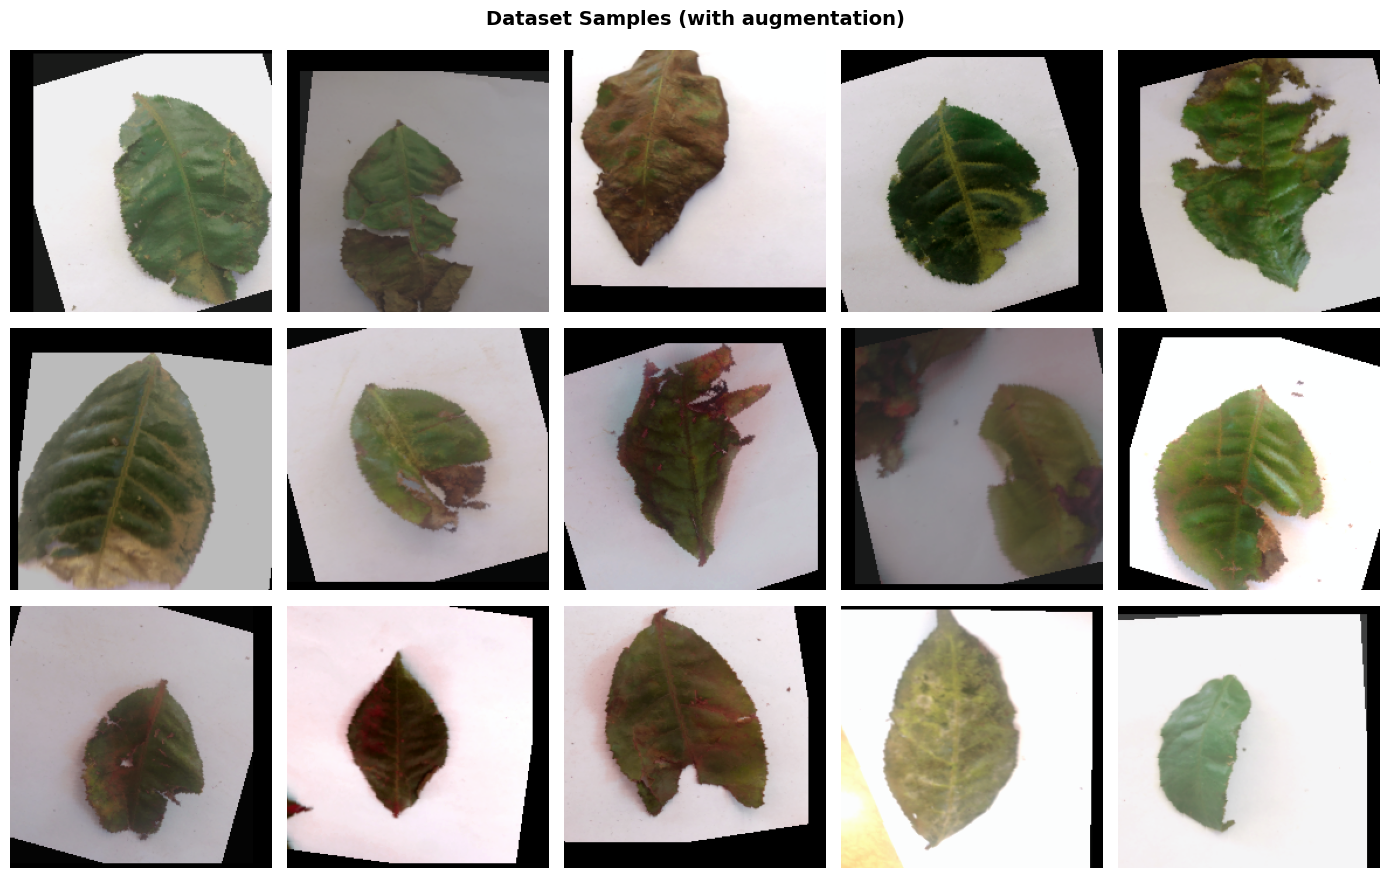

In [5]:
def imshow(tensor, ax, title=''):
    img = tensor.numpy().transpose(1, 2, 0)
    img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)
    ax.imshow(img); ax.axis('off')
    if title: ax.set_title(title, fontsize=9, fontweight='bold')

def plot_dataset_grid(loader, idx_to_class, n_per_class=5):
    classes_seen = {}
    for images, labels in loader:
        for img, lbl in zip(images, labels):
            cls = idx_to_class[lbl.item()]
            classes_seen.setdefault(cls, []).append(img)
        if all(len(v) >= n_per_class for v in classes_seen.values()): break
    fig, axes = plt.subplots(3, n_per_class, figsize=(14, 9))
    fig.suptitle('Dataset Samples (with augmentation)', fontsize=14, fontweight='bold')
    for row, cls in enumerate(sorted(classes_seen)):
        for col in range(n_per_class):
            imshow(classes_seen[cls][col], axes[row][col])
            if col == 0: axes[row][col].set_ylabel(cls.title(), fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.savefig('dataset_grid.png', dpi=120, bbox_inches='tight'); plt.show()

plot_dataset_grid(loaders['train'], idx_to_class)


## 6. Model Architecture

### VGG16
- Backbone: 13 convolutional layers (pre-trained on ImageNet, mostly frozen)
- Last 2 conv blocks fine-tuned
- Custom classifier: `25088 → 1024 → 256 → 3` with Dropout

### ResNet50
- Backbone: 50-layer residual network (pre-trained on ImageNet)
- `layer4` (last residual block) fine-tuned
- Custom FC head: `2048 → 512 → 3` with Dropout

In [6]:
NUM_CLASSES = len(class_names)

def build_vgg16(num_classes):
    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False
    for layer in list(model.features.children())[-6:]:   # unfreeze last 2 conv blocks
        for param in layer.parameters():
            param.requires_grad = True
    model.classifier = nn.Sequential(
        nn.Linear(25088, 1024), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(1024, 256),  nn.ReLU(inplace=True), nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model

def build_resnet50(num_classes):
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512), nn.ReLU(inplace=True), nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

vgg_model    = build_vgg16(NUM_CLASSES).to(DEVICE)
resnet_model = build_resnet50(NUM_CLASSES).to(DEVICE)

for name, m in [('VGG16', vgg_model), ('ResNet50', resnet_model)]:
    total, trainable = count_params(m)
    print(f'{name}: {total:,} params total | {trainable:,} trainable ({trainable/total*100:.1f}%)')


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.1MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


VGG16: 40,668,995 params total | 30,673,923 trainable (75.4%)
ResNet50: 24,558,659 params total | 16,015,363 trainable (65.2%)


## 7. Training

| Setting | Value |
|---------|-------|
| Optimizer | AdamW |
| Loss | CrossEntropyLoss (label smoothing 0.1) |
| LR Scheduler | CosineAnnealingLR |
| Gradient clipping | max_norm = 1.0 |
| Epochs | 25 |
| Best model selection | Highest validation accuracy |

In [7]:
def train_model(model, loaders, sizes, cfg, model_name):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg['LR'], weight_decay=cfg['WEIGHT_DECAY']
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg['NUM_EPOCHS'], eta_min=cfg['LR'] * 0.01)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_acc, best_wts = 0.0, copy.deepcopy(model.state_dict())
    t0 = time.time()

    for epoch in range(1, cfg['NUM_EPOCHS'] + 1):
        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss, running_correct = 0.0, 0
            for inputs, labels in loaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)
                    preds   = outputs.argmax(dim=1)
                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                        optimizer.step()
                running_loss    += loss.item() * inputs.size(0)
                running_correct += (preds == labels).sum().item()
            epoch_loss = running_loss / sizes[phase]
            epoch_acc  = running_correct / sizes[phase]
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_wts = copy.deepcopy(model.state_dict())
        scheduler.step()
        if epoch % 5 == 0 or epoch == 1:
            print(f'[{model_name}] Ep {epoch:02d}/{cfg["NUM_EPOCHS"]}  '
                  f'Train={history["train_acc"][-1]:.4f}  '
                  f'Val={history["val_acc"][-1]:.4f}  '
                  f'LR={scheduler.get_last_lr()[0]:.2e}  '
                  f'[{time.time()-t0:.0f}s]')

    print(f'\n✅ [{model_name}] Done in {time.time()-t0:.0f}s | Best Val Acc: {best_acc:.4f}')
    model.load_state_dict(best_wts)
    return model, history

print('Training VGG16 ...')
vgg_model, vgg_hist = train_model(vgg_model, loaders, sizes, CFG, 'VGG16')

print('\nTraining ResNet50 ...')
resnet_model, resnet_hist = train_model(resnet_model, loaders, sizes, CFG, 'ResNet50')


Training VGG16 ...
[VGG16] Ep 01/25  Train=0.3735  Val=0.5094  LR=9.96e-05  [7s]
[VGG16] Ep 05/25  Train=0.7237  Val=0.8302  LR=9.05e-05  [27s]
[VGG16] Ep 10/25  Train=0.8405  Val=0.7547  LR=6.58e-05  [53s]
[VGG16] Ep 15/25  Train=0.8755  Val=0.8113  LR=3.52e-05  [80s]
[VGG16] Ep 20/25  Train=0.9339  Val=0.7736  LR=1.05e-05  [106s]
[VGG16] Ep 25/25  Train=0.9494  Val=0.8113  LR=1.00e-06  [132s]

✅ [VGG16] Done in 132s | Best Val Acc: 0.8491

Training ResNet50 ...
[ResNet50] Ep 01/25  Train=0.4708  Val=0.5283  LR=9.96e-05  [5s]
[ResNet50] Ep 05/25  Train=0.8716  Val=0.7358  LR=9.05e-05  [25s]
[ResNet50] Ep 10/25  Train=0.8911  Val=0.8679  LR=6.58e-05  [50s]
[ResNet50] Ep 15/25  Train=0.9533  Val=0.8679  LR=3.52e-05  [75s]
[ResNet50] Ep 20/25  Train=0.9572  Val=0.8679  LR=1.05e-05  [103s]
[ResNet50] Ep 25/25  Train=0.9883  Val=0.8679  LR=1.00e-06  [127s]

✅ [ResNet50] Done in 127s | Best Val Acc: 0.9245


## 8. Evaluation

In [8]:
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            preds = model(inputs.to(device)).argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

y_true_vgg,    y_pred_vgg    = evaluate(vgg_model,    loaders['test'], DEVICE)
y_true_resnet, y_pred_resnet = evaluate(resnet_model, loaders['test'], DEVICE)

print('VGG16 — Test Set')
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names))
print('ResNet50 — Test Set')
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))


VGG16 — Test Set
              precision    recall  f1-score   support

  algal leaf       0.89      0.94      0.92        18
brown blight       0.87      0.72      0.79        18
  white spot       0.75      0.82      0.78        22

    accuracy                           0.83        58
   macro avg       0.84      0.83      0.83        58
weighted avg       0.83      0.83      0.83        58

ResNet50 — Test Set
              precision    recall  f1-score   support

  algal leaf       0.94      0.83      0.88        18
brown blight       0.84      0.89      0.86        18
  white spot       0.87      0.91      0.89        22

    accuracy                           0.88        58
   macro avg       0.88      0.88      0.88        58
weighted avg       0.88      0.88      0.88        58



## 9. Training Curves & Confusion Matrices

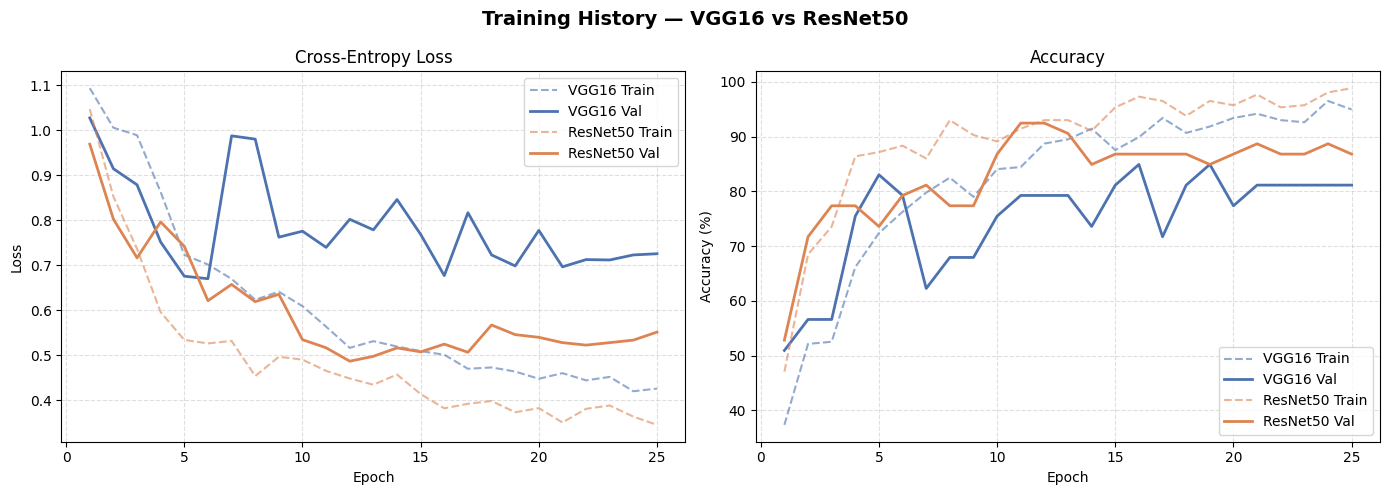

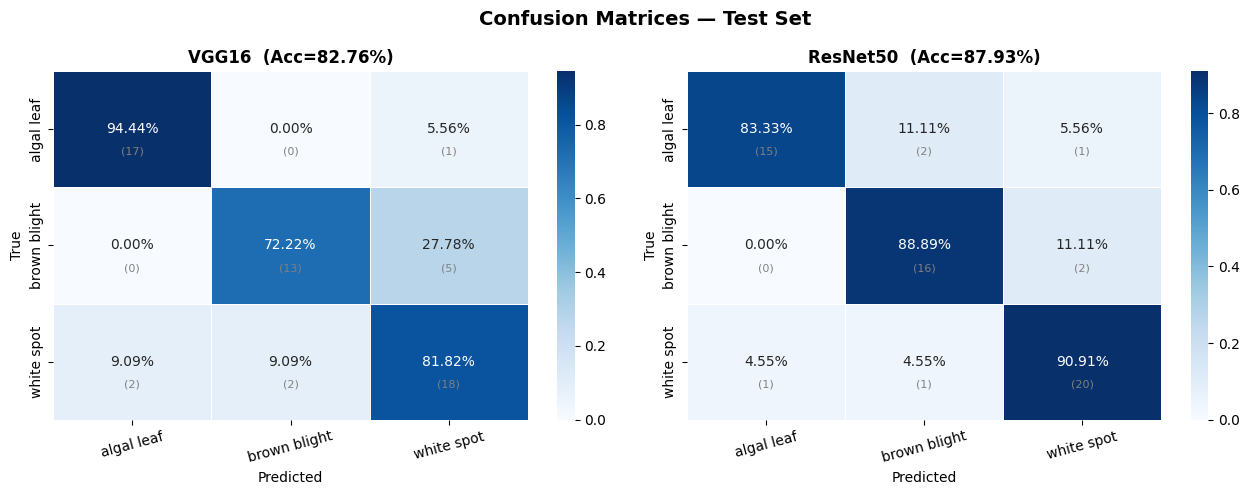

In [9]:
# ── Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — VGG16 vs ResNet50', fontsize=14, fontweight='bold')
epochs = range(1, CFG['NUM_EPOCHS'] + 1)
for name, hist, color in [('VGG16', vgg_hist, COLORS['VGG16']), ('ResNet50', resnet_hist, COLORS['ResNet50'])]:
    axes[0].plot(epochs, hist['train_loss'], '--', color=color, alpha=0.6, label=f'{name} Train')
    axes[0].plot(epochs, hist['val_loss'],   '-',  color=color, lw=2,      label=f'{name} Val')
    axes[1].plot(epochs, [a*100 for a in hist['train_acc']], '--', color=color, alpha=0.6, label=f'{name} Train')
    axes[1].plot(epochs, [a*100 for a in hist['val_acc']],   '-',  color=color, lw=2,      label=f'{name} Val')
axes[0].set(title='Cross-Entropy Loss', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy (%)')
for ax in axes: ax.legend(); ax.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# ── Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
for ax, name, yt, yp in zip(axes,
                              ['VGG16', 'ResNet50'],
                              [y_true_vgg, y_true_resnet],
                              [y_pred_vgg, y_pred_resnet]):
    cm = confusion_matrix(yt, yp)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_n, annot=True, fmt='.2%', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                cmap='Blues', linewidths=0.5, linecolor='white')
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j+0.5, i+0.72, f'({cm[i,j]})', ha='center', fontsize=8, color='grey')
    acc = np.trace(cm) / cm.sum()
    ax.set_title(f'{name}  (Acc={acc:.2%})', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()


## 10. Performance Comparison

Metric                              VGG16        ResNet50
---------------------------------------------------------
Test Accuracy                      82.76%          87.93%
Precision (macro)                  83.71%          88.31%
Recall (macro)                     82.83%          87.71%
F1-Score (macro)                   82.98%          87.87%
Best Val Accuracy                  84.91%          92.45%


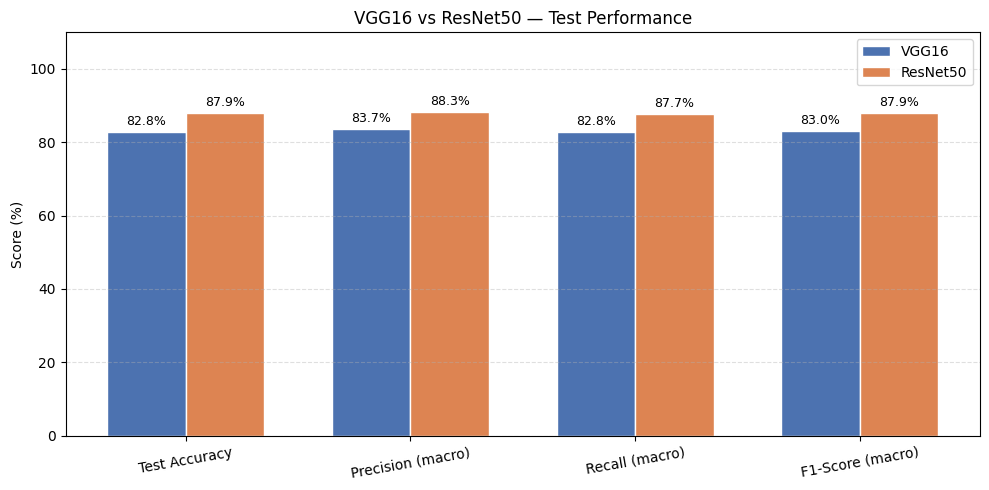

In [10]:
def get_metrics(name, y_true, y_pred, hist):
    return {
        'Model': name,
        'Test Accuracy':      f"{accuracy_score(y_true, y_pred)*100:.2f}%",
        'Precision (macro)':  f"{precision_score(y_true, y_pred, average='macro', zero_division=0)*100:.2f}%",
        'Recall (macro)':     f"{recall_score(y_true, y_pred, average='macro', zero_division=0)*100:.2f}%",
        'F1-Score (macro)':   f"{f1_score(y_true, y_pred, average='macro', zero_division=0)*100:.2f}%",
        'Best Val Accuracy':  f"{max(hist['val_acc'])*100:.2f}%",
    }

rows = [get_metrics('VGG16',    y_true_vgg,    y_pred_vgg,    vgg_hist),
        get_metrics('ResNet50', y_true_resnet, y_pred_resnet, resnet_hist)]

print(f"{'Metric':<25} {'VGG16':>15} {'ResNet50':>15}")
print('-' * 57)
for key in rows[0]:
    if key != 'Model':
        print(f"{key:<25} {rows[0][key]:>15} {rows[1][key]:>15}")

# Bar chart
metrics   = ['Test Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
vgg_vals  = [float(rows[0][m].rstrip('%')) for m in metrics]
res_vals  = [float(rows[1][m].rstrip('%')) for m in metrics]
x, width  = np.arange(len(metrics)), 0.35
fig, ax   = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, vgg_vals, width, label='VGG16',    color=COLORS['VGG16'],    edgecolor='white')
b2 = ax.bar(x + width/2, res_vals, width, label='ResNet50', color=COLORS['ResNet50'], edgecolor='white')
ax.bar_label(b1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.1f%%', padding=3, fontsize=9)
ax.set(title='VGG16 vs ResNet50 — Test Performance', ylabel='Score (%)', ylim=(0, 110))
ax.set_xticks(x); ax.set_xticklabels(metrics, rotation=10)
ax.legend(); ax.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout(); plt.savefig('comparison_bar.png', dpi=150, bbox_inches='tight'); plt.show()


## 11. Qualitative Predictions

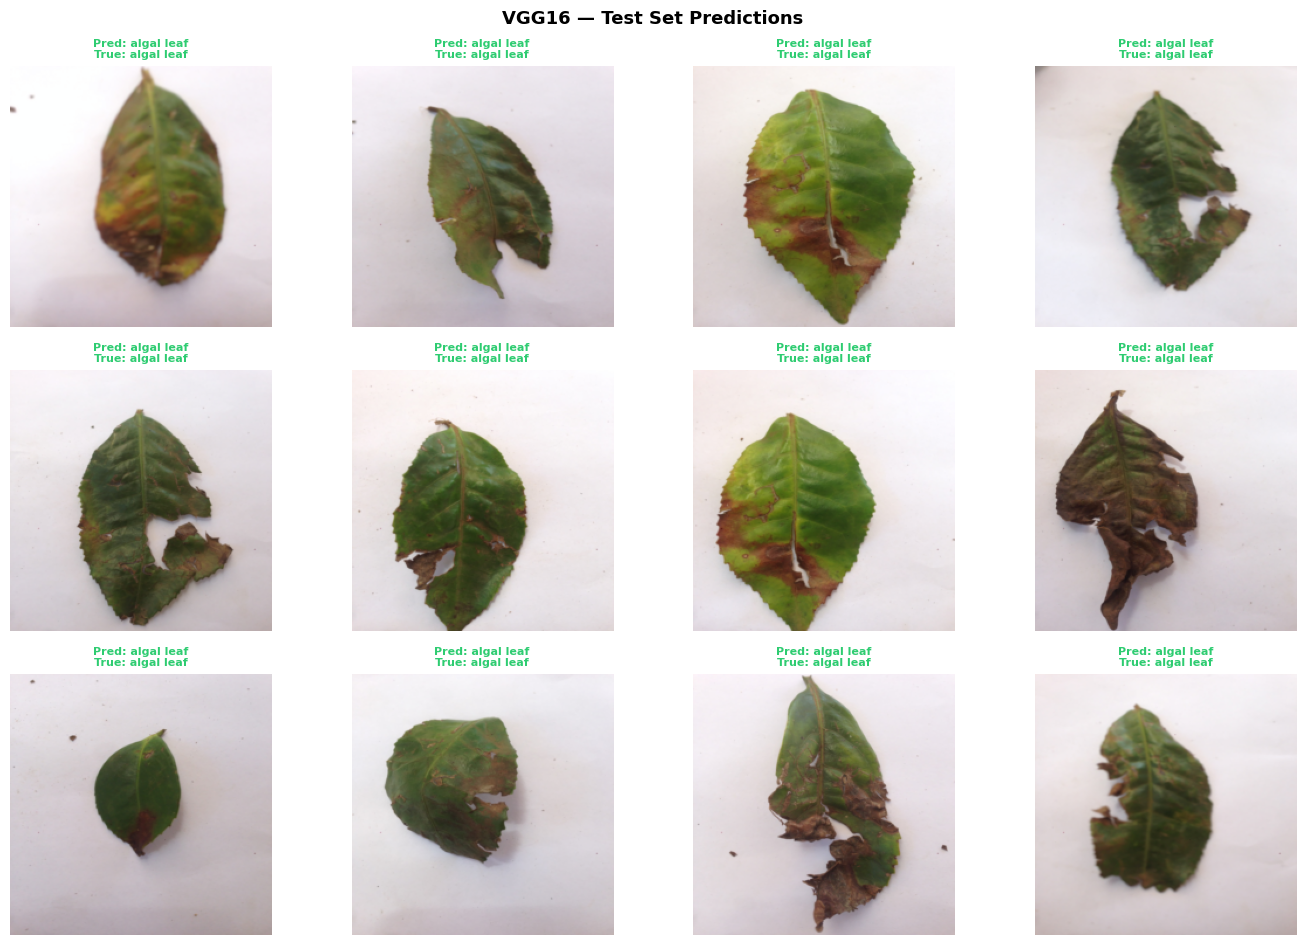

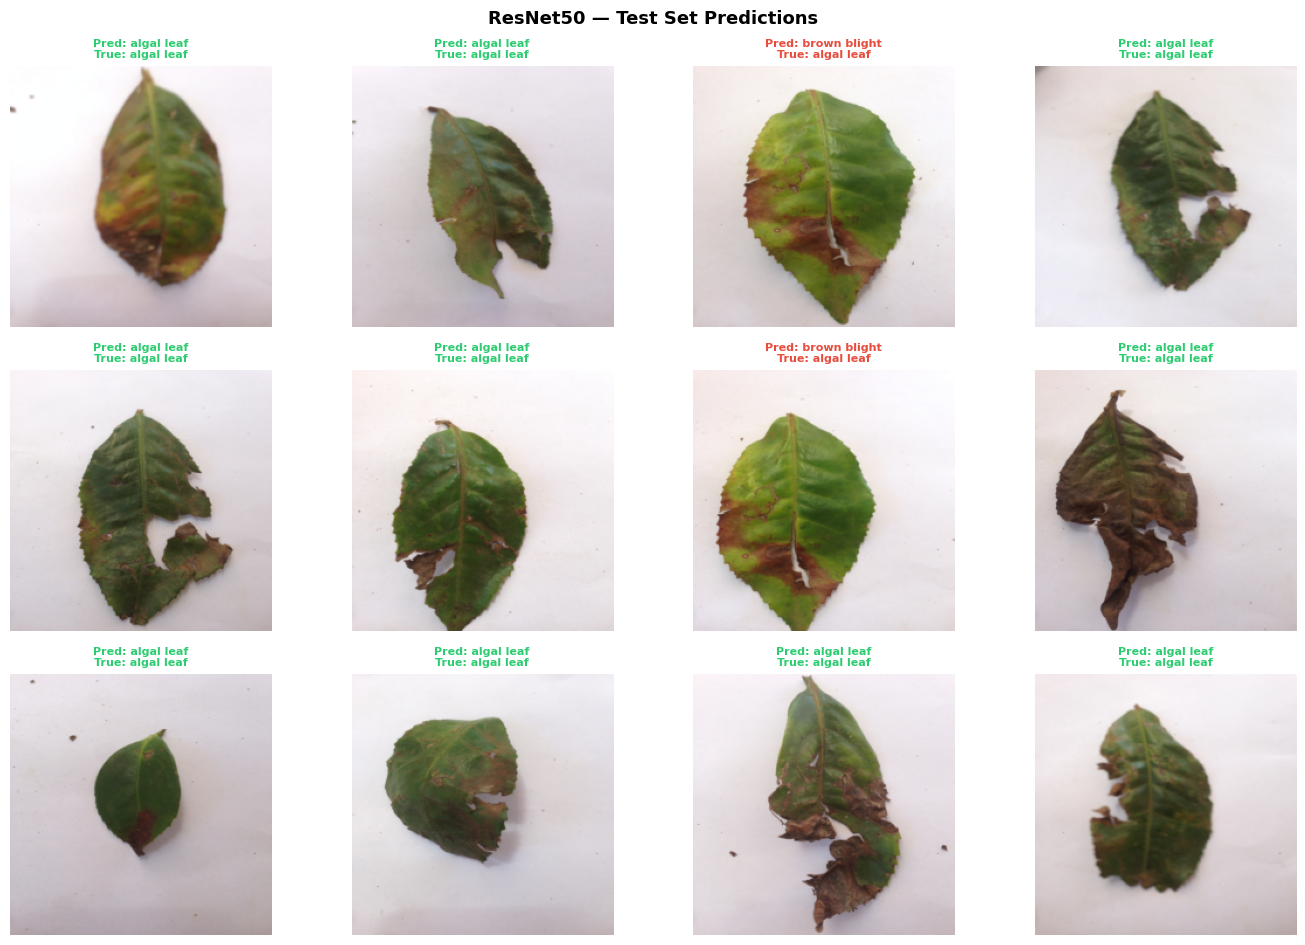

In [11]:
def plot_predictions(model, loader, idx_to_class, device, n=12, title='Model'):
    model.eval()
    imgs_s, preds_s, true_s = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            outs = model(imgs.to(device)).argmax(dim=1).cpu()
            imgs_s.extend(imgs); preds_s.extend(outs.numpy()); true_s.extend(lbls.numpy())
            if len(imgs_s) >= n: break
    cols, rows = 4, -(-n // 4)
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.2))
    fig.suptitle(f'{title} — Test Set Predictions', fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i >= n: ax.axis('off'); continue
        imshow(imgs_s[i], ax)
        pred = idx_to_class[preds_s[i]]; true = idx_to_class[true_s[i]]
        color = '#2ecc71' if pred == true else '#e74c3c'
        ax.set_title(f'Pred: {pred}\nTrue: {true}', fontsize=8, color=color, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'predictions_{title.lower().replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

plot_predictions(vgg_model,    loaders['test'], idx_to_class, DEVICE, n=12, title='VGG16')
plot_predictions(resnet_model, loaders['test'], idx_to_class, DEVICE, n=12, title='ResNet50')


## 12. Save Models & Outputs

In [13]:
torch.save(vgg_model.state_dict(),    'vgg16_tea_disease.pth')
torch.save(resnet_model.state_dict(), 'resnet50_tea_disease.pth')
print('✅ Models saved.')

# Zip all outputs for download
import zipfile
out_files = [
    'training_curves.png', 'confusion_matrices.png', 'comparison_bar.png',
    'predictions_vgg16.png', 'predictions_resnet50.png', 'dataset_grid.png',
    'vgg16_tea_disease.pth', 'resnet50_tea_disease.pth'
]
with zipfile.ZipFile('outputs.zip', 'w') as z:
    for f in out_files:
        if os.path.exists(f): z.write(f)
print('✅ outputs.zip ready — download from Colab file browser.')


✅ Models saved.
✅ outputs.zip ready — download from Colab file browser.
